In [88]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 

import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [89]:
# causal cnn with dilation 
# used for comparison later with bare tcn 
class CausalCNNDilated(nn.Module): 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 16, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8, 16), 
            verbose: bool = False
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, 1) 

    @property 
    def receptive_field(self) -> int: 
        return 1 + (self.kernel - 1) * sum(self.dilations) 
    
    def assert_receptive_field(self, x): 
        window = x.shape[-1] 
        assert window >= self.receptive_field, (
            f"Window={window} < RF={self.receptive_field}"
            "Deeper layers will convolve mostly over padding zeros."
            "Increase window or reduce dilations"
        ) 
    
    def forward(self, x): 
        self.assert_receptive_field(x)
        for d, conv in zip(self.dilations, self.convs): 
            pad = (self.kernel - 1) * d # pad scales with dilations 
            x = F.pad(x, (pad, 0)) 
            x = F.relu(conv(x)) 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1] 
        return self.head(x).squeeze(-1) 


In [90]:
class TCN(nn.Module): 
    """ 
    Bare TCN is just CausalCNNDilated + residual connections 
    """ 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 16, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8 ,16), 
            verbose: bool = False 
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        # 1x1 projections for layer 0 only (in_ch -> hidden mismatch) 
        self.skip_proj = nn.Conv1d(in_ch, hidden, kernel_size=1) if in_ch != hidden else None 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, 1) 
    
    @property 
    def receptive_field(self) -> int: 
        return 1 + (self.kernel - 1) * sum(self.dilations) 
    
    def assert_receptive_field(self, x): 
        window = x.shape[-1] 
        assert window >= self.receptive_field, (
            f"Window={window} < RF={self.receptive_field}"
            "Deeper layers will convolve mostly over padding zeros."
            "Increase window or reduce dilations"
        ) 

    def forward(self, x): 
        self.assert_receptive_field(x)
        for i, (d, conv) in enumerate(zip(self.dilations, self.convs)): 
            pad = (self.kernel - 1) * d 
            x_padded = F.pad(x, (pad, 0)) 
            out = F.relu(conv(x_padded)) 

            # residual connections 
            if i == 0 and self.skip_proj is not None: 
                residual = self.skip_proj(x) 
            else: 
                residual = x
            x = out + residual 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1]
        return self.head(x).squeeze(-1)

In [91]:
model = TCN(in_ch=1, hidden=16, kernel=3, dilations=(1, 2, 4, 8, 16), verbose=True)
x = torch.randn(8, 1, 64)              # batch=8, channel=1, time=64
y = model(x)
print("\nOutput shape:", y.shape)      # expect: torch.Size([8])

after conv (d=1): torch.Size([8, 16, 64])
after conv (d=2): torch.Size([8, 16, 64])
after conv (d=4): torch.Size([8, 16, 64])
after conv (d=8): torch.Size([8, 16, 64])
after conv (d=16): torch.Size([8, 16, 64])

Output shape: torch.Size([8])


In [92]:

# Failure case — should raise AssertionError
try:
    x_small = torch.randn(8, 1, 32)                    # window=32 < RF=63
    model(x_small)
except AssertionError as e:
    print(f"\nCaught expected error: {e}")


Caught expected error: Window=32 < RF=63Deeper layers will convolve mostly over padding zeros.Increase window or reduce dilations


In [93]:
def generate_synthetic_dataset(ar: int = 20): 
    np.random.seed(67) 
    n = 5000 
    sigma = 1.0 
    phi = np.zeros(ar) 
    phi[0] = 0.5 
    phi[ar-1] = 0.4 

    y = np.zeros(n) 
    y[:ar] = np.random.randn(ar) * sigma 

    for t in range(ar, n): 
        eps = np.random.randn() * sigma 
        y[t] = np.dot(phi, y[t-ar:t][::-1]) + eps 
    return y  


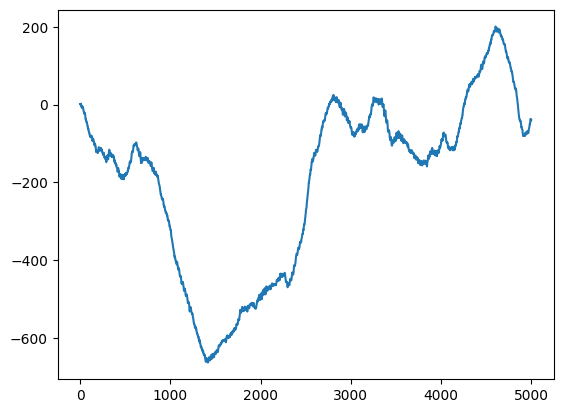

In [94]:
data = generate_synthetic_dataset() 
plt.plot(data.cumsum()) 

In [95]:

def preprocess_data(data, window: int=64, train_test_split: float=0.8): 
    data_tensor = torch.from_numpy(data).float() 
    windows = data_tensor.unfold(0, window+1, 1) 
    X = windows[:, :-1].unsqueeze(1) 
    Y = windows[:, -1] 

    print(X.shape)
    print(Y.shape)

    split = int(0.8 * len(X)) 
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]

    zero_pred_mse = (Y_test ** 2).mean().item()    # if returns are mean ~0, this ≈ var
    print(f"Predict-zero baseline MSE: {zero_pred_mse:.6f}")

    train_ds = TensorDataset(X_train, Y_train)
    test_ds  = TensorDataset(X_test,  Y_test)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)   # shuffle ok within train
    test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)  # don't shuffle test 
    return train_loader, test_loader, zero_pred_mse

train_loader, test_loader, _= preprocess_data(data)  


torch.Size([4936, 1, 64])
torch.Size([4936])
Predict-zero baseline MSE: 1.963137


In [96]:
from datetime import datetime 

def train_test_loop(
        model: nn.Module, 
        train_loader: DataLoader, 
        test_loader: DataLoader, 
        zero_pred_mse: float,
        lr: float = 1e-3, 
        epochs:int = 25
    ): 
    start = datetime.now() 
    loss_fn = nn.MSELoss() 
    optimizer = optim.Adam(model.parameters(), lr=lr) 
    for epoch in range(epochs): 
        model.train() 
        running_loss = 0.0 
        for xb, yb in train_loader: 
            optimizer.zero_grad() 
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward() 
            optimizer.step() 
            running_loss += loss.item() 
        avg_loss = running_loss / len(train_loader)
        # print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}")
    end = datetime.now() 
    training_time = (end-start).total_seconds() 
    print(f"Total Training Time: {training_time:.1f} seconds") 

    # test loop 
    model.eval() 
    test_loss = 0
    test_losses = []
    with torch.no_grad(): 
        for xb, yb in test_loader: 
            pred = model(xb) 
            loss = loss_fn(pred, yb) 
            test_loss += loss.item() 
            test_losses.append(loss.item())
    test_mse = test_loss / len(test_loader)
    print(f"Test MSE: {test_mse:.6f}")
    print(f"Bayes-optimal floor (σ²): 1.0")
    print(f"Gap: {test_mse - 1.0:.6f}")  
    print(f"Predict-zero baseline MSE: {zero_pred_mse:.6f}")
    print(f"OOS R²: {1 - test_mse/zero_pred_mse:.4f}")
    return test_mse, np.array(test_losses)


In [97]:
# train and test causal cnn 
causal_cnn_test_mse, causal_cnn_test_losses = train_test_loop(
    CausalCNNDilated(), 
    train_loader=train_loader, 
    test_loader=test_loader,
    zero_pred_mse=_
)

Total Training Time: 11.8 seconds
Test MSE: 1.083633
Bayes-optimal floor (σ²): 1.0
Gap: 0.083633
Predict-zero baseline MSE: 1.963137
OOS R²: 0.4480


In [98]:
tcn_test_mse, tcn_test_losses = train_test_loop( 
    TCN(), 
    train_loader=train_loader, 
    test_loader=test_loader, 
    zero_pred_mse=_
)

Total Training Time: 17.2 seconds
Test MSE: 1.054360
Bayes-optimal floor (σ²): 1.0
Gap: 0.054360
Predict-zero baseline MSE: 1.963137
OOS R²: 0.4629


In [99]:
import yfinance as yf
data = yf.download('GC=F') 
data.columns = data.columns.droplevel('Ticker') 
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [100]:
log_returns = np.log(data["Close"] / data["Close"].shift(1)).dropna()

In [101]:
train_loader, test_loader, zero_pred_mse = preprocess_data(log_returns.to_numpy()) 

torch.Size([6381, 1, 64])
torch.Size([6381])
Predict-zero baseline MSE: 0.000132


In [102]:
tcn_test_mse, tcn_test_losses = train_test_loop( 
    TCN(), 
    train_loader=train_loader, 
    test_loader=test_loader,
    zero_pred_mse=zero_pred_mse
)

Total Training Time: 22.5 seconds
Test MSE: 0.000138
Bayes-optimal floor (σ²): 1.0
Gap: -0.999862
Predict-zero baseline MSE: 0.000132
OOS R²: -0.0433
